In [ ]:
#I3D tried using pretrained weights
import os
import sys
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
import zipfile
import subprocess

print("--- Initializing the Heavyweight I3D Video Experiment ---")

# --- THE BULLETPROOF FIX ---
os.chdir('/kaggle/working')
i3d_path = '/kaggle/working/WLASL/code/I3D/pytorch_i3d.py'
if not os.path.exists(i3d_path):
    print("WLASL repository is missing! Redownloading it now...")
    subprocess.run(['rm', '-rf', '/kaggle/working/WLASL'])
    subprocess.run(['git', 'clone', 'https://github.com/dxli94/WLASL.git', '/kaggle/working/WLASL'])
    print("Download complete!")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sys.path.append('/kaggle/working/WLASL/code/I3D')

try:
    from pytorch_i3d import InceptionI3d
    print("Successfully imported I3D model architecture!")
except Exception as e:
    print(f" Critical Import Error: {e}")
    raise e
# ----------------------------------------------------------------

# 1. Smarter Hunt for YOUR RAW MP4 Videos Folder
all_mp4s = glob.glob('/kaggle/input/**/*.mp4', recursive=True)

# Filter out the massive ASL dataset so the AI only looks at YOUR custom PSL dataset
psl_mp4s = [f for f in all_mp4s if 'WLASL/data/videos' not in f.replace('\\', '/')]

if len(psl_mp4s) == 0:
    raise FileNotFoundError(" Could not find your custom .mp4 files! Did you attach your original WLPSL dataset?")

# Deduce your custom Videos folder based on where your MP4s actually live
first_psl_mp4 = psl_mp4s[0]
raw_videos_dir = os.path.dirname(os.path.dirname(first_psl_mp4))
print(f"Found YOUR Raw Videos at: {raw_videos_dir}")

# Dynamically build the class dictionary
class_names = sorted([d for d in os.listdir(raw_videos_dir) if os.path.isdir(os.path.join(raw_videos_dir, d))]) 
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
num_classes = len(class_to_idx)
print(f"Discovered {num_classes} PSL classes.")

# 2. Define the I3D RGB Video Dataset
class PSLVideoDataset(Dataset):
    def __init__(self, file_list, target_frames=64, img_size=224, is_train=False):
        self.file_list = file_list
        self.target_frames = target_frames
        self.img_size = img_size
        self.is_train = is_train

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        
        # Open the MP4 file using OpenCV
        cap = cv2.VideoCapture(file_path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            # Convert from OpenCV BGR to PyTorch RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Resize to 224x224 (I3D Standard)
            frame = cv2.resize(frame, (self.img_size, self.img_size))
            frames.append(frame)
        cap.release()
        
        frames = np.array(frames) # Shape: [Total_Frames, H, W, Channels]
        total_frames = frames.shape[0]
        
        # Handle empty/corrupted videos
        if total_frames == 0:
            frames = np.zeros((self.target_frames, self.img_size, self.img_size, 3), dtype=np.uint8)
            total_frames = self.target_frames
            
        # Pad or sample exactly 64 frames
        if total_frames >= self.target_frames:
            # Evenly sample frames
            indices = np.linspace(0, total_frames - 1, self.target_frames).astype(int)
            frames = frames[indices]
        else:
            # Pad with black frames if too short
            pad_len = self.target_frames - total_frames
            pad_frames = np.zeros((pad_len, self.img_size, self.img_size, 3), dtype=np.uint8)
            frames = np.concatenate([frames, pad_frames], axis=0)

        # Basic Augmentation (Random Horizontal Flip)
        if self.is_train and random.random() > 0.5:
            frames = np.flip(frames, axis=2).copy()

        # Normalize pixels from 0-255 to 0-1
        frames = frames.astype(np.float32) / 255.0
        
        # Reshape for I3D: from [T, H, W, C] to [Channels, Time, Height, Width]
        tensor = torch.from_numpy(frames).permute(3, 0, 1, 2)
        
        # Read the real label from the file path
        parent_folder = os.path.basename(os.path.dirname(file_path))
        label = class_to_idx[parent_folder]
        
        return tensor, torch.tensor(label, dtype=torch.long)

# 3. Prepare Data Loaders (Hunting for MP4s!)
print("\n--- Preparing RGB Video Data Loaders ---")
all_mp4s = glob.glob(f'{raw_videos_dir}/**/*.mp4', recursive=True)

if len(all_mp4s) == 0:
    raise FileNotFoundError("Could not find the .mp4 files! Make sure your WLPSL dataset is attached.")

random.seed(42)
random.shuffle(all_mp4s)

train_size = int(0.8 * len(all_mp4s))
train_files = all_mp4s[:train_size]
test_files = all_mp4s[train_size:]

train_dataset = PSLVideoDataset(train_files, is_train=True)
test_dataset = PSLVideoDataset(test_files, is_train=False)

# BATCH SIZE IS 2 TO PREVENT VRAM CRASHES!
train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=3, shuffle=False)

print(f"Data Split: {len(train_dataset)} Training Videos | {len(test_dataset)} Testing Videos")

# 4. Model Injection & Freezing Functions
def get_fresh_i3d_model():
    # Standard I3D is born to predict 400 action classes (Kinetics)
    model = InceptionI3d(400, in_channels=3)
    
    # Hunt for pre-trained I3D weights (if you uploaded them), otherwise load standard
    weight_paths = glob.glob('/kaggle/input/**/*.pt', recursive=True) 
    
    if len(weight_paths) > 0:
        print(f"  -> Found pre-trained weights: {weight_paths[0]}")
        try:
            model.load_state_dict(torch.load(weight_paths[0], map_location=device))
        except:
            print("  -> Could not perfectly map weights. Injecting what fits...")
            pretrained_dict = torch.load(weight_paths[0], map_location=device)
            model_dict = model.state_dict()
            filtered_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and v.shape == model_dict[k].shape}
            model_dict.update(filtered_dict)
            model.load_state_dict(model_dict)
    else:
        print("  -> No pre-trained I3D weights found in Kaggle inputs. Starting with an empty I3D Brain!")
        
    # Replace the final 400-class layer with our 31-class layer
    model.replace_logits(num_classes)
    return model.to(device)

def apply_zero_shot(model):
    for param in model.parameters(): param.requires_grad = False

def apply_linear_probe(model):
    for param in model.parameters(): param.requires_grad = False
    # Unfreeze the very last classification layer we just replaced
    for param in model.logits.parameters():
        param.requires_grad = True

def apply_partial_ft(model):
    for param in model.parameters(): param.requires_grad = False
    # Unfreeze the final mixed block of the network
    for param in model.Mixed_5c.parameters(): param.requires_grad = True
    for param in model.logits.parameters(): param.requires_grad = True

def apply_full_ft(model):
    for param in model.parameters(): param.requires_grad = True 
# 5. Training & Evaluation Engine
def run_stage(stage_name, freeze_function, epochs=15, lr=0.001):
    print(f"\n{'='*40}\n  Starting Stage: {stage_name}\n{'='*40}")
    model = get_fresh_i3d_model()
    freeze_function(model)
    
    criterion = nn.CrossEntropyLoss()
    
    if stage_name != "Zero-Shot":
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
        
        for epoch in range(1, epochs + 1):
            model.train()
            total_loss = 0.0
            
            for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                
                # I3D returns a tuple, we only need the first element (logits)
                predictions = model(batch_x)
                if isinstance(predictions, tuple): predictions = predictions[0]
                
                # THE FIX: Average the predictions across the 7 time chunks!
                predictions = predictions.mean(dim=-1).squeeze()
                
                loss = criterion(predictions, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                
            print(f"  Epoch {epoch}/{epochs} | Train Loss: {total_loss/len(train_loader):.4f}")
    
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            if isinstance(outputs, tuple): outputs = outputs[0]
            
            # THE FIX: Average the outputs across the time chunks!
            outputs = outputs.mean(dim=-1).squeeze()
            
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            
    test_acc = (correct / total) * 100
    print(f"  {stage_name} Test Accuracy: {test_acc:.2f}%")
    
    ckpt_path = f"{CKPT_DIR}/{stage_name.replace(' ', '_')}.pth"
    torch.save(model.state_dict(), ckpt_path)
    
    return {'acc': test_acc, 'preds': all_preds, 'labels': all_labels, 'ckpt': ckpt_path}
# 6. Execute the Experiment (EPOCHS ARE LOWERED BECAUSE I3D IS HEAVY!)
results = {}
results['Zero-Shot']    = run_stage("Zero-Shot", apply_zero_shot, epochs=0) 
results['Linear Probe'] = run_stage("Linear Probe", apply_linear_probe, epochs=15, lr=0.001)
results['Partial FT']   = run_stage("Partial FT", apply_partial_ft, epochs=15, lr=0.0005)
results['Full FT']      = run_stage("Full FT", apply_full_ft, epochs=15, lr=0.0001)

# 7. Result Matrix
print("\n" + "="*40 + "\n           I3D RESULT MATRIX \n" + "="*40)
best_stage = max(results, key=lambda k: results[k]['acc'])
for stage, data in results.items():
    marker = " <-- BEST!" if stage == best_stage else ""
    print(f"  {stage.ljust(15)} : {data['acc']:>6.2f}% {marker}")

# 8. Confusion Matrix
print("\n--- Generating Confusion Matrix ---")
best_preds, best_labels = results[best_stage]['preds'], results[best_stage]['labels']
cm = confusion_matrix(best_labels, best_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title(f"I3D Confusion Matrix ({best_stage})", fontsize=16)
plt.xlabel("Predicted Sign", fontsize=12)
plt.ylabel("Actual Sign", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

cm_path = f"{OUTPUT_DIR}/i3d_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
print(f"Saved Confusion Matrix to {cm_path}")

# 9. Zip Export
print("\n--- Zipping Results and Checkpoints ---")
zip_path = '/kaggle/working/I3D_Experiment_Results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in os.listdir(OUTPUT_DIR): zipf.write(f"{OUTPUT_DIR}/{f}", f"i3d_outputs/{f}")
    for f in os.listdir(CKPT_DIR): zipf.write(f"{CKPT_DIR}/{f}", f"i3d_checkpoints/{f}")

print(f"Success! I3D experiment complete and packaged in '{zip_path}'.")

--- 🚀 Initializing the Heavyweight I3D Video Experiment ---
✅ Successfully imported I3D model architecture!
✅ Found YOUR Raw Videos at: /kaggle/input/datasets/jahanzebnaeem/wlpsl/WLPSL/Videos
Discovered 31 PSL classes.

--- Preparing RGB Video Data Loaders ---
Data Split: 198 Training Videos | 50 Testing Videos

  Starting Stage: Full FT
  -> Successfully targeted pre-trained weights: /kaggle/input/datasets/emaimkaggle/i3d-pertrained-weights/FINAL_nslt_100_iters896_top165.89_top584.11_top1089.92.pt
  -> Partial match layout detected. Injecting valid layers into the network...
  Epoch 1/15 | Train Loss: 3.4976
  Epoch 2/15 | Train Loss: 3.2291
  Epoch 3/15 | Train Loss: 2.9920
  Epoch 4/15 | Train Loss: 2.8030
  Epoch 5/15 | Train Loss: 2.5547
  Epoch 6/15 | Train Loss: 2.2573
  Epoch 7/15 | Train Loss: 1.9984
  Epoch 8/15 | Train Loss: 1.8058
  Epoch 9/15 | Train Loss: 1.6415
  Epoch 10/15 | Train Loss: 1.4015
  Epoch 11/15 | Train Loss: 1.2634
  Epoch 12/15 | Train Loss: 1.1449
  Epoc

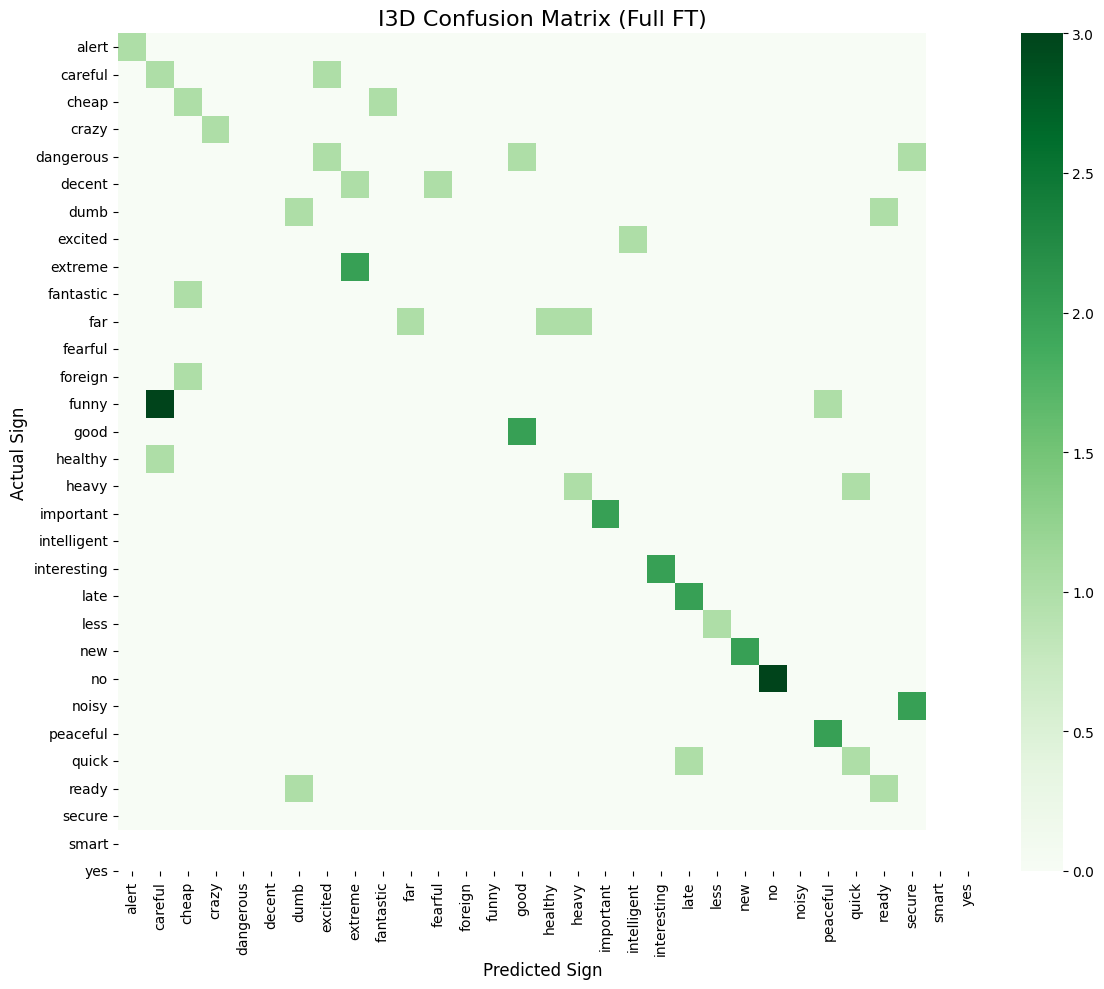

In [ ]:
# I3D using pretrained weights
import os
import sys
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
import zipfile
import subprocess

print("--- Initializing the Heavyweight I3D Video Experiment ---")

# --- THE BULLETPROOF FIX ---
os.chdir('/kaggle/working')
i3d_path = '/kaggle/working/WLASL/code/I3D/pytorch_i3d.py'
if not os.path.exists(i3d_path):
    print("WLASL repository is missing! Redownloading it now...")
    subprocess.run(['rm', '-rf', '/kaggle/working/WLASL'])
    subprocess.run(['git', 'clone', 'https://github.com/dxli94/WLASL.git', '/kaggle/working/WLASL'])
    print("Download complete!")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sys.path.append('/kaggle/working/WLASL/code/I3D')

# Define paths to prevent NameErrors later
OUTPUT_DIR = '/kaggle/working/outputs'
CKPT_DIR = '/kaggle/working/checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

try:
    from pytorch_i3d import InceptionI3d
    print("Successfully imported I3D model architecture!")
except Exception as e:
    print(f"Critical Import Error: {e}")
    raise e
# ----------------------------------------------------------------

# 1. Smarter Hunt for YOUR RAW MP4 Videos Folder
all_mp4s = glob.glob('/kaggle/input/**/*.mp4', recursive=True)

# Filter out the massive ASL dataset so the AI only looks at YOUR custom PSL dataset
psl_mp4s = [f for f in all_mp4s if 'WLASL/data/videos' not in f.replace('\\', '/')]

if len(psl_mp4s) == 0:
    raise FileNotFoundError("Could not find your custom .mp4 files! Did you attach your original WLPSL dataset?")

# Deduce your custom Videos folder based on where your MP4s actually live
first_psl_mp4 = psl_mp4s[0]
raw_videos_dir = os.path.dirname(os.path.dirname(first_psl_mp4))
print(f"Found YOUR Raw Videos at: {raw_videos_dir}")

# Dynamically build the class dictionary
class_names = sorted([d for d in os.listdir(raw_videos_dir) if os.path.isdir(os.path.join(raw_videos_dir, d))]) 
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
num_classes = len(class_to_idx)
print(f"Discovered {num_classes} PSL classes.")

# 2. Define the I3D RGB Video Dataset
class PSLVideoDataset(Dataset):
    def __init__(self, file_list, target_frames=64, img_size=224, is_train=False):
        self.file_list = file_list
        self.target_frames = target_frames
        self.img_size = img_size
        self.is_train = is_train

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        
        cap = cv2.VideoCapture(file_path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (self.img_size, self.img_size))
            frames.append(frame)
        cap.release()
        
        frames = np.array(frames)
        total_frames = frames.shape[0]
        
        if total_frames == 0:
            frames = np.zeros((self.target_frames, self.img_size, self.img_size, 3), dtype=np.uint8)
            total_frames = self.target_frames
            
        if total_frames >= self.target_frames:
            indices = np.linspace(0, total_frames - 1, self.target_frames).astype(int)
            frames = frames[indices]
        else:
            pad_len = self.target_frames - total_frames
            pad_frames = np.zeros((pad_len, self.img_size, self.img_size, 3), dtype=np.uint8)
            frames = np.concatenate([frames, pad_frames], axis=0)

        if self.is_train and random.random() > 0.5:
            frames = np.flip(frames, axis=2).copy()

        frames = frames.astype(np.float32) / 255.0
        tensor = torch.from_numpy(frames).permute(3, 0, 1, 2)
        
        parent_folder = os.path.basename(os.path.dirname(file_path))
        label = class_to_idx[parent_folder]
        
        return tensor, torch.tensor(label, dtype=torch.long)

# 3. Prepare Data Loaders
print("\n--- Preparing RGB Video Data Loaders ---")
all_mp4s = glob.glob(f'{raw_videos_dir}/**/*.mp4', recursive=True)

random.seed(42)
random.shuffle(all_mp4s)

train_size = int(0.8 * len(all_mp4s))
train_files = all_mp4s[:train_size]
test_files = all_mp4s[train_size:]

train_dataset = PSLVideoDataset(train_files, is_train=True)
test_dataset = PSLVideoDataset(test_files, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=3, shuffle=False)

print(f"Data Split: {len(train_dataset)} Training Videos | {len(test_dataset)} Testing Videos")

# 4. Model Injection & Freezing Functions (UPDATED FOR SPECIFIC WEIGHT PATH)
def get_fresh_i3d_model():
    model = InceptionI3d(400, in_channels=3)
    
    # Target path explicitly defined by you
    target_weight_dir = '/kaggle/input/datasets/emaimkaggle/i3d-pertrained-weights'
    
    # Hunt for .pt or .pth files inside your specific folder
    weight_paths = glob.glob(os.path.join(target_weight_dir, '**/*.pt'), recursive=True) + \
                   glob.glob(os.path.join(target_weight_dir, '**/*.pth'), recursive=True)
    
    # Fallback to search all inputs if the specific folder structure is slightly different
    if len(weight_paths) == 0:
        weight_paths = glob.glob('/kaggle/input/**/*.pt', recursive=True)
        
    if len(weight_paths) > 0:
        print(f"  -> Successfully targeted pre-trained weights: {weight_paths[0]}")
        try:
            model.load_state_dict(torch.load(weight_paths[0], map_location=device))
        except:
            print("  -> Partial match layout detected. Injecting valid layers into the network...")
            pretrained_dict = torch.load(weight_paths[0], map_location=device)
            model_dict = model.state_dict()
            filtered_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and v.shape == model_dict[k].shape}
            model_dict.update(filtered_dict)
            model.load_state_dict(model_dict)
    else:
        print("  -> No pre-trained weights found at all. Starting with an empty I3D Brain!")
        
    model.replace_logits(num_classes)
    return model.to(device)

def apply_zero_shot(model):
    for param in model.parameters(): param.requires_grad = False

def apply_linear_probe(model):
    for param in model.parameters(): param.requires_grad = False
    for param in model.logits.parameters():
        param.requires_grad = True

def apply_partial_ft(model):
    for param in model.parameters(): param.requires_grad = False
    for param in model.Mixed_5c.parameters(): param.requires_grad = True
    for param in model.logits.parameters(): param.requires_grad = True

def apply_full_ft(model):
    for param in model.parameters(): param.requires_grad = True 

# 5. Training & Evaluation Engine
def run_stage(stage_name, freeze_function, epochs=15, lr=0.001):
    print(f"\n{'='*40}\n  Starting Stage: {stage_name}\n{'='*40}")
    model = get_fresh_i3d_model()
    freeze_function(model)
    
    criterion = nn.CrossEntropyLoss()
    
    if stage_name != "Zero-Shot":
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
        
        for epoch in range(1, epochs + 1):
            model.train()
            total_loss = 0.0
            
            for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                
                predictions = model(batch_x)
                if isinstance(predictions, tuple): predictions = predictions[0]
                
                predictions = predictions.mean(dim=-1).squeeze()
                
                loss = criterion(predictions, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                
            print(f"  Epoch {epoch}/{epochs} | Train Loss: {total_loss/len(train_loader):.4f}")
    
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            if isinstance(outputs, tuple): outputs = outputs[0]
            
            outputs = outputs.mean(dim=-1).squeeze()
            
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            
    test_acc = (correct / total) * 100
    print(f"  {stage_name} Test Accuracy: {test_acc:.2f}%")
    
    ckpt_path = f"{CKPT_DIR}/{stage_name.replace(' ', '_')}.pth"
    torch.save(model.state_dict(), ckpt_path)
    
    return {'acc': test_acc, 'preds': all_preds, 'labels': all_labels, 'ckpt': ckpt_path}

# 6. Execute the Experiment
results = {}
#results['Zero-Shot']    = run_stage("Zero-Shot", apply_zero_shot, epochs=0) 
#results['Linear Probe'] = run_stage("Linear Probe", apply_linear_probe, epochs=15, lr=0.001)
results['Full FT']      = run_stage("Full FT", apply_full_ft, epochs=15, lr=0.0001)
results['Partial FT']   = run_stage("Partial FT", apply_partial_ft, epochs=15, lr=0.0005)

# 7. Result Matrix
print("\n" + "="*40 + "\n         I3D RESULT MATRIX \n" + "="*40)
best_stage = max(results, key=lambda k: results[k]['acc'])
for stage, data in results.items():
    marker = " <-- BEST!" if stage == best_stage else ""
    print(f"  {stage.ljust(15)} : {data['acc']:>6.2f}% {marker}")

# 8. Confusion Matrix
print("\n--- Generating Confusion Matrix ---")
best_preds, best_labels = results[best_stage]['preds'], results[best_stage]['labels']
cm = confusion_matrix(best_labels, best_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title(f"I3D Confusion Matrix ({best_stage})", fontsize=16)
plt.xlabel("Predicted Sign", fontsize=12)
plt.ylabel("Actual Sign", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

cm_path = f"{OUTPUT_DIR}/i3d_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
print(f"Saved Confusion Matrix to {cm_path}")

# 9. Zip Export
print("\n--- Zipping Results and Checkpoints ---")
zip_path = '/kaggle/working/I3D_Experiment_Results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in os.listdir(OUTPUT_DIR): zipf.write(f"{OUTPUT_DIR}/{f}", f"i3d_outputs/{f}")
    for f in os.listdir(CKPT_DIR): zipf.write(f"{CKPT_DIR}/{f}", f"i3d_checkpoints/{f}")

print(f"Success! I3D experiment complete and packaged in '{zip_path}'.")